# Marker Repo - annotation

In this notebook, clustered h5ad files can be annotated using the marker repo.

## Loading packages

In [ ]:
import markerrepo.marker_repo as mr
import markerrepo.wrappers as wrap
import markerrepo.annotation as annot
import scanpy as sc

%load_ext autoreload
%autoreload 2

## Settings

Specify path of the cloned repository, the h5ad file which is going to be annotated as well as the organism.

In [2]:
repo_path = "/mnt/workspace/mkessle/projects/annotate_by_marker_and_features"
h5ad_path = "/mnt/agnerds/user/micha.kessler/zebrafish.h5ad"
organism = mr.select(key="organism")
rank_genes_column = None

Select organism
1:	human 9606
2:	mouse 10090
3:	zebrafish 7955
4:	rat 10114
5:	pig 9823
6:	medaka 8090
7:	chicken 9031
8:	drosophila 7215
9:	yeast 4932
3
Selection: zebrafish 7955



Load anndata

In [3]:
adata = sc.read_h5ad(h5ad_path)

In [4]:
adata.var

,gene_ids,n_cells,is_mito,is_ribo,n_cells_by_counts,mean_counts,log1p_mean_counts,highly_variable,means,dispersions,dispersions_norm
cep97,ENSDARG00000102407,1352,False,False,1352,0.051758,0.050463,False,0.036510,0.037585,-0.375943
eed,ENSDARG00000099640,4842,False,False,4842,0.219490,0.198432,False,0.148197,0.079252,-0.261616
hikeshi,ENSDARG00000104071,9491,False,False,9492,0.495413,0.402403,False,0.317790,0.091204,-0.604207
tmem39a,ENSDARG00000102746,6925,False,False,6927,0.378297,0.320849,False,0.222810,0.077175,-0.267316
ildr1a,ENSDARG00000103929,35,False,False,35,0.001249,0.001249,False,0.000907,-0.068862,-0.668015
...,...,...,...,...,...,...,...,...,...,...,...
NC_002333.10,ENSDARG00000081443,135,False,False,135,0.004962,0.004949,False,0.003549,0.001472,-0.475032
NC_002333.4,ENSDARG00000080337,27601,False,False,27614,23.232876,3.187710,False,3.106818,3.057679,0.292659
NC_002333.12,ENSDARG00000081758,192,False,False,192,0.006889,0.006866,False,0.007026,0.333548,0.436125
NC_002333.3,ENSDARG00000080329,36,False,False,36,0.001285,0.001284,False,0.001150,0.281445,0.293164


## Prepare adata

### Set genes to index, if not already done.

Pick the genes column.

In [ ]:
genes_column = mr.select(whitelist=list(adata.var.columns), heading="genes column")

In [ ]:
adata.var.reset_index(inplace=True)  # remove peaks from index and save them in the column ['index']
adata.var.set_index(genes_column, inplace=True)  # set genes as index
adata.var.index = adata.var.index.astype('str')  # to avoid index being categorical
adata.var_names_make_unique(join='_')

In [ ]:
adata.var

## Prepare annotation

### Ranking

Pick the clustring column you want to annotate.

In [5]:
column = mr.select(whitelist=list(adata.obs.columns), heading="clustering column")

Select clustering column
1:	Sample
2:	timepoint
3:	n_genes_by_counts
4:	total_counts
5:	log1p_total_counts
6:	pct_counts_is_mito
7:	pct_counts_is_ribo
8:	n_genes
9:	S_score
10:	G2M_score
11:	phase
12:	leiden
12
Selection: leiden



Pick the rank genes column, if the anndata object already contains one.

In [ ]:
list(adata.uns.keys())

In [ ]:
rank_genes_column = mr.select(whitelist=list(adata.uns.keys()), heading="genes column")

Rank genes, if not already done.

In [6]:
if not rank_genes_column:
    # adata.uns['log1p']['base'] = None
    rank_genes_column = f'rank_genes_groups_{column}'
    print(f'Ranking genes groups for clusters using obs column {column}')
    sc.tl.rank_genes_groups(adata, groupby=f'{column}', use_raw=False, key_added=rank_genes_column)

Ranking genes groups for clusters using obs column leiden


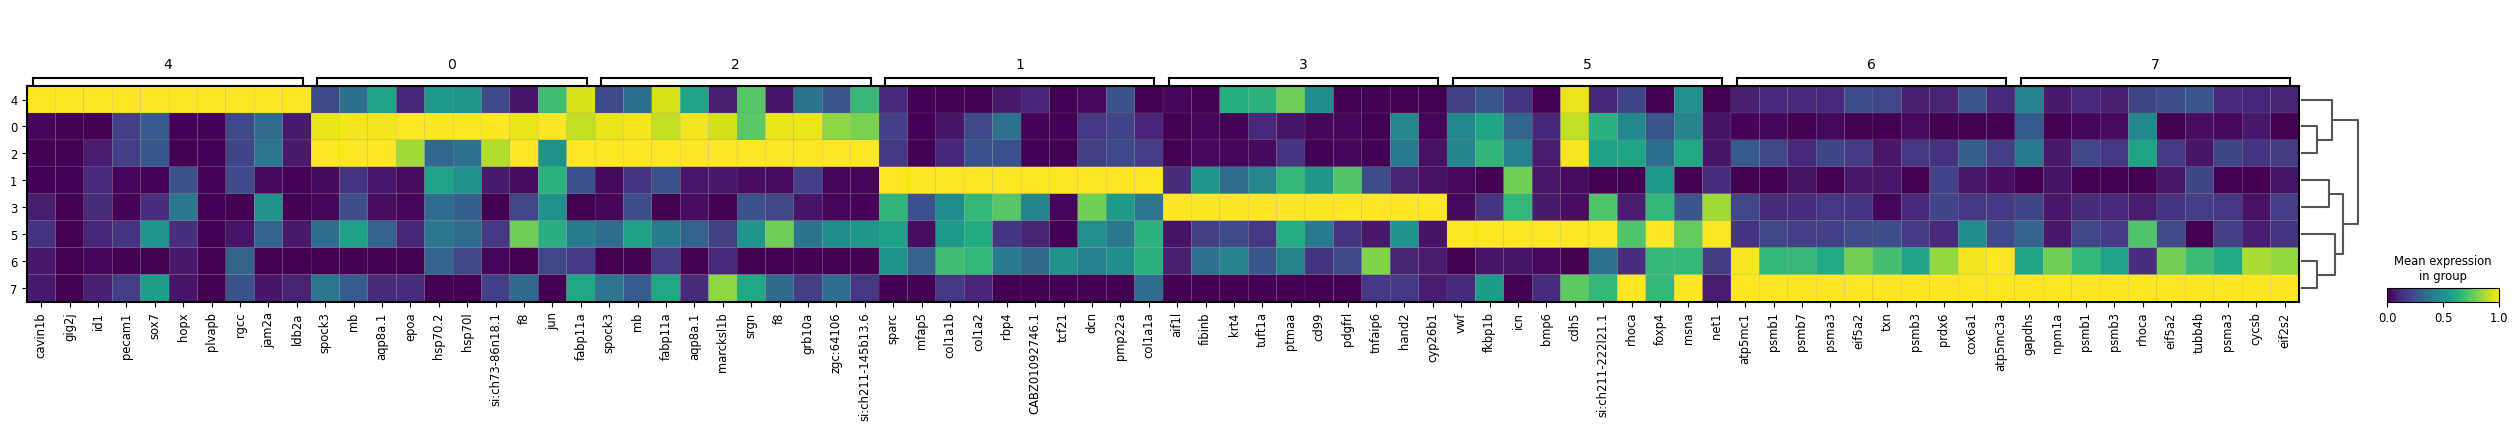

In [7]:
sc.pl.rank_genes_groups_matrixplot(adata, standard_scale='var', n_genes=10, key=rank_genes_column, show=True)

## Create suitable marker list(s)

No marker lists found for this organism.
Trying to create marker lists via homology...
Fetching whitelists...
Done!

Loading genes of zebrafish...
Done!

Select lists of source markers.
Available columns for search:
1: List name
2: Marker type
3: Organism name
4: Taxonomy ID
5: Submitter name
6: List type
7: Source
8: tags_transferred
9: Date
10: Email
n: Next page
Enter identifier of column to search in (leave blank to search in all columns): 7
Do you want to see all unique entries in this column? (yes/no) yes
Unique entries:
bio-bigdata.hrbmu.edu.cn/CellMarker
panglao.se
nan
panglao
Enter search terms (separated by commas, '-' for negative search): panglao.se
Perform an exact search? (yes/no): no
Consider case sensitivity? (yes/no): no
Number of results: 60
Do you want to see the results? (yes/no): no
Do you want to continue searching? (yes/no): no

The following source organisms can be used in both approaches: mouse 10090, human 9606.

Starting HomoloGene approach...
Loading genes o

,Marker,Info
0,SLC26A4 ENSMUSG00000020651,Chromaffin cells
1,AGRP ENSMUSG00000005705,Chromaffin cells
2,IGF2 ENSMUSG00000048583,Chromaffin cells
3,SNAP25 ENSMUSG00000027273,Chromaffin cells
4,SLC18A2 ENSMUSG00000025094,Chromaffin cells
...,...,...
8079,PIWIL2 ENSMUSG00000033644,Embryonic stem cells
8080,PIWIL4 ENSMUSG00000036912,Embryonic stem cells
8081,LIFR ENSMUSG00000054263,Embryonic stem cells
8082,IL6ST ENSMUSG00000021756,Embryonic stem cells


Filter source DataFrame by the number of target genes per source gene: remove all source genes that lead to more than 1 target genes.
Marker transfer rate: 79.21%
Marker transfer rate after filtering: 59.95%
Possible transfer rate of all genes: 25.35%
Proportion of transferred genes in all genes of target organism: 32.30%

Count of target genes per source gene:


,Source Gene,Count target genes
185,AA987161,655
12048,ZFP738 ENSMUSG00000048280,655
179,A530054K11RIK,655
7526,PCDHB3 ENSMUSG00000045498,63
7301,OLFR935 ENSMUSG00000059595,25
...,...,...
4325,GMIP ENSMUSG00000036246,1
4326,GMNC ENSMUSG00000068428,1
4327,GMNN ENSMUSG00000006715,1
4328,GMPPA ENSMUSG00000033021,1


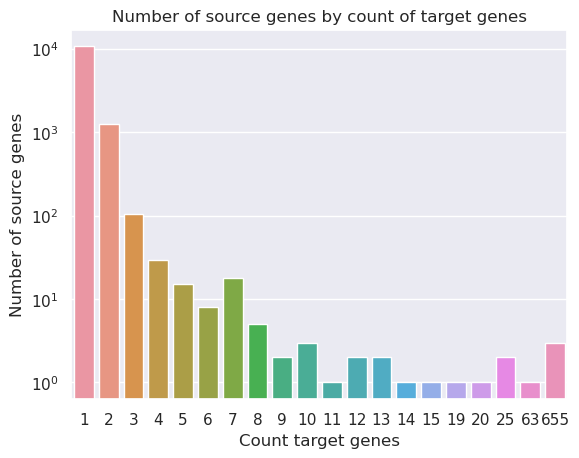

Filtered source DataFrame with target_counts <= 1:


,Marker,Info
0,SLC26A4 ENSMUSG00000020651,Chromaffin cells
1,SLC26A4 ENSMUSG00000020651,Platelets
2,SLC26A4 ENSMUSG00000020651,Intercalated cells
3,SLC26A4 ENSMUSG00000020651,Transient cells
4,SNAP25 ENSMUSG00000027273,Chromaffin cells
...,...,...
4136,HMGA2 ENSMUSG00000056758,Embryonic stem cells
4137,NACC1 ENSMUSG00000001910,Embryonic stem cells
4138,GDF3 ENSMUSG00000030117,Embryonic stem cells
4139,SMAD2 ENSMUSG00000024563,Embryonic stem cells


Filtered: 3943 source genes, 48.78%
Create DataFrame containing the transferred genes based on the filter criteria.
Marker transfer rate: 99.90%
Marker transfer rate after filtering: 82.81%
Possible transfer rate of all genes: 25.35%
Proportion of transferred genes in all genes of target organism: 32.30%
Transferred markers:


,Marker,Info
0,SLC26A4 ENSDARG00000069431,Chromaffin cells
1,SLC26A4 ENSDARG00000069431,Platelets
2,SLC26A4 ENSDARG00000069431,Intercalated cells
3,SLC26A4 ENSDARG00000069431,Transient cells
4,SNAP25A ENSDARG00000020609,Chromaffin cells
...,...,...
4136,HMGA2 ENSDARG00000069912,Embryonic stem cells
4137,LOC572093,Embryonic stem cells
4138,DVR1,Embryonic stem cells
4139,SMAD2 ENSDARG00000006389,Embryonic stem cells


Transferring Panglao ubiquitousness index to zebrafish...
Selection: drerio

Weighted transferred markers:


,Marker,Info,Score
2777,OTOGL ENSDARG00000088750,Goblet cells,0.0
3700,RNF121 ENSDARG00000060282,Olfactory epithelial cells,0.0
1494,TBXAS1 ENSDARG00000002249,Microglia,0.0
3950,MYD88 ENSDARG00000010169,Myoblasts,0.0
2703,SLC26A2 ENSDARG00000011618,Enterocytes,0.0
...,...,...,...
1240,ISL1 ENSDARG00000004023,Enteroendocrine cells,1.0
1239,ISL1 ENSDARG00000004023,Photoreceptor cells,1.0
1235,ISL1 ENSDARG00000004023,Motor neurons,1.0
1245,ISL1 ENSDARG00000004023,Pancreatic progenitor cells,1.0


Enter file name: 1
Marker list saved: /mnt/workspace/mkessle/projects/annotate_by_marker_and_features/notebooks/transferred_markers/1
Loading genes of human...
Done!

Get HomoloGene db...

DataFrame of the markers of the source organism (human) to be transferred to the target organism (zebrafish):


,Marker,Info
0,SLC26A4 ENSG00000091137,Chromaffin cells
1,AGRP ENSG00000159723,Chromaffin cells
2,IGF2 ENSG00000167244,Chromaffin cells
3,SNAP25 ENSG00000132639,Chromaffin cells
4,SLC18A2 ENSG00000165646,Chromaffin cells
...,...,...
8045,PIWIL1 ENSG00000125207,Embryonic stem cells
8046,PIWIL2 ENSG00000197181,Embryonic stem cells
8047,PIWIL4 ENSG00000134627,Embryonic stem cells
8048,LIFR ENSG00000113594,Embryonic stem cells


Filter source DataFrame by the number of target genes per source gene: remove all source genes that lead to more than 1 target genes.
Marker transfer rate: 79.43%
Marker transfer rate after filtering: 60.17%
Possible transfer rate of all genes: 23.07%
Proportion of transferred genes in all genes of target organism: 31.58%

Count of target genes per source gene:


,Source Gene,Count target genes
12026,ZNF729 ENSG00000196350,655
7444,PCDHB3 ENSG00000113205,63
7442,PCDHA8 ENSG00000204962,40
4651,HIST2H2BE,31
7237,OR8G5 ENSG00000255298,25
...,...,...
4293,GPR142 ENSG00000257008,1
4294,GPR143 ENSG00000101850,1
4295,GPR144,1
4296,GPR146 ENSG00000164849,1


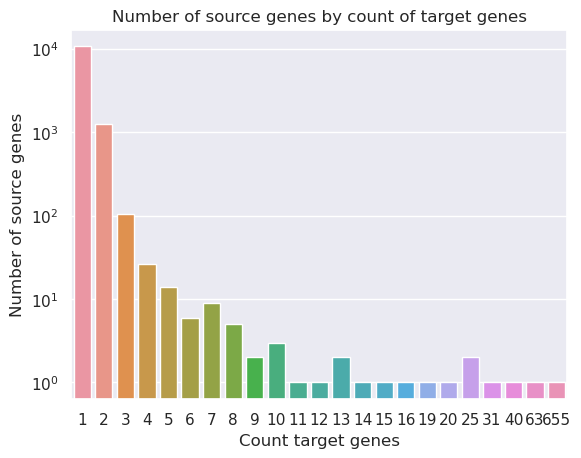

Filtered source DataFrame with target_counts <= 1:


,Marker,Info
0,SLC26A4 ENSG00000091137,Chromaffin cells
1,SLC26A4 ENSG00000091137,Platelets
2,SLC26A4 ENSG00000091137,Intercalated cells
3,SLC26A4 ENSG00000091137,Transient cells
4,SNAP25 ENSG00000132639,Chromaffin cells
...,...,...
4116,TAF8 ENSG00000137413,Embryonic stem cells
4117,NACC1 ENSG00000160877,Embryonic stem cells
4118,GDF3 ENSG00000184344,Embryonic stem cells
4119,SMAD2 ENSG00000175387,Embryonic stem cells


Filtered: 3929 source genes, 48.81%
Create DataFrame containing the transferred genes based on the filter criteria.
Marker transfer rate: 100.00%
Marker transfer rate after filtering: 83.01%
Possible transfer rate of all genes: 23.07%
Proportion of transferred genes in all genes of target organism: 31.58%
Transferred markers:


,Marker,Info
0,SLC26A4 ENSDARG00000069431,Chromaffin cells
1,SLC26A4 ENSDARG00000069431,Platelets
2,SLC26A4 ENSDARG00000069431,Intercalated cells
3,SLC26A4 ENSDARG00000069431,Transient cells
4,SNAP25A ENSDARG00000020609,Chromaffin cells
...,...,...
4116,TAF8 ENSDARG00000026806,Embryonic stem cells
4117,LOC572093,Embryonic stem cells
4118,DVR1,Embryonic stem cells
4119,SMAD2 ENSDARG00000006389,Embryonic stem cells


Transferring Panglao ubiquitousness index to zebrafish...
Selection: drerio

Weighted transferred markers:


,Marker,Info,Score
2527,ITM2BA ENSDARG00000007098,Müller cells,0.0
1864,MRPS28 ENSDARG00000041538,Purkinje neurons,0.0
1859,ATP2B2 ENSDARG00000063433,Purkinje neurons,0.0
4088,MICAL2B ENSDARG00000020395,Endothelial cells (aorta),0.0
3003,FADS2 ENSDARG00000019532,Basophils,0.0
...,...,...,...
1240,ISL1 ENSDARG00000004023,Pancreatic progenitor cells,1.0
1237,ISL1 ENSDARG00000004023,Beta cells,1.0
1233,ISL1 ENSDARG00000004023,Retinal ganglion cells,1.0
1234,ISL1 ENSDARG00000004023,Photoreceptor cells,1.0


Enter file name: 2
Marker list saved: /mnt/workspace/mkessle/projects/annotate_by_marker_and_features/notebooks/transferred_markers/2

Starting BioMart approach...

Specify BioMart target organism selection:
Selection: drerio


Specify BioMart source organism selection:
Default organism: mmusculus
Loading genes of mouse...
Done!

Fetch necessary data from BioMart...

DataFrame of the markers of the source organism (mouse) to be transferred to the target organism (zebrafish):


,Marker,Info
0,SLC26A4 ENSMUSG00000020651,Chromaffin cells
1,AGRP ENSMUSG00000005705,Chromaffin cells
2,IGF2 ENSMUSG00000048583,Chromaffin cells
3,SNAP25 ENSMUSG00000027273,Chromaffin cells
4,SLC18A2 ENSMUSG00000025094,Chromaffin cells
...,...,...
8079,PIWIL2 ENSMUSG00000033644,Embryonic stem cells
8080,PIWIL4 ENSMUSG00000036912,Embryonic stem cells
8081,LIFR ENSMUSG00000054263,Embryonic stem cells
8082,IL6ST ENSMUSG00000021756,Embryonic stem cells


Filter source DataFrame by the number of target genes per source gene: remove all source genes that lead to more than 1 target genes.
Marker transfer rate: 127.68%
Marker transfer rate after filtering: 126.46%
Possible transfer rate of all genes: 41.89%
Proportion of transferred genes in all genes of target organism: 71.67%

Count of target genes per source gene:


,Source Gene,Count target genes
3227,TRAC ENSMUSG00000076928,37
1700,CD22 ENSMUSG00000030577,35
3226,TRDV1 ENSMUSG00000076864,32
3139,HTRA2 ENSMUSG00000068329,25
999,MS4A7 ENSMUSG00000024672,24
...,...,...
1329,SNX16 ENSMUSG00000027534,1
1330,NFATC2 ENSMUSG00000027544,1
1331,SALL4 ENSMUSG00000027547,1
1335,COL9A3 ENSMUSG00000027570,1


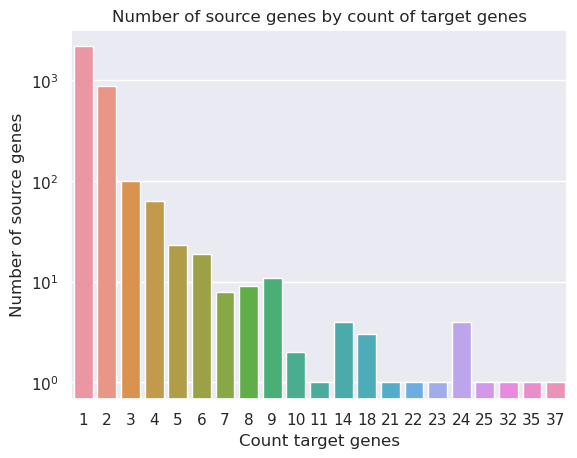

Filtered source DataFrame with target_counts <= 1:


,Marker,Info
0,SLC26A4 ENSMUSG00000020651,Chromaffin cells
1,SLC26A4 ENSMUSG00000020651,Platelets
2,SLC26A4 ENSMUSG00000020651,Intercalated cells
3,SLC26A4 ENSMUSG00000020651,Transient cells
4,AGRP ENSMUSG00000005705,Chromaffin cells
...,...,...
3735,TAF8 ENSMUSG00000023980,Embryonic stem cells
3736,HMGA2 ENSMUSG00000056758,Embryonic stem cells
3737,ESRRB ENSMUSG00000021255,Embryonic stem cells
3738,PIWIL1 ENSMUSG00000029423,Embryonic stem cells


Filtered: 4344 source genes, 53.74%
Create DataFrame containing the transferred genes based on the filter criteria.
Marker transfer rate: 100.00%
Marker transfer rate after filtering: 99.01%
Possible transfer rate of all genes: 41.89%
Proportion of transferred genes in all genes of target organism: 71.67%
Transferred markers:


,Marker,Info
0,CDH2 ENSDARG00000018693,Hematopoietic stem cells
1,HGD ENSDARG00000058005,Proximal tubule cells
2,DSC2L ENSDARG00000039677,Keratinocytes
5,SI:CH73-74H11.1 ENSDARG00000062750,Trichocytes
6,LMNB1 ENSDARG00000044299,Erythroblasts
...,...,...
3735,EHF ENSDARG00000052115,Delta cells
3736,EHF ENSDARG00000052115,Langerhans cells
3737,SPRED1 ENSDARG00000041449,Mast cells
3738,LRRC57 ENSDARG00000043938,Germ cells


Transferring Panglao ubiquitousness index to zebrafish...
Weighted transferred markers:


,Marker,Info,Score
2276,DUOX2 ENSDARG00000078962,Acinar cells,0.0
2137,FZD6 ENSDARG00000104874,Epithelial cells,0.0
3342,BDNF ENSDARG00000018817,Cardiomyocytes,0.0
1942,MYCN ENSDARG00000006837,Hematopoietic stem cells,0.0
949,SI:DKEY-42P14.3 ENSDARG00000092825,Olfactory epithelial cells,0.0
...,...,...,...
162,SI:DKEY-30C15.12 ENSDARG00000058546,Luminal epithelial cells,1.0
158,SI:DKEY-30C15.12 ENSDARG00000058546,Plasmacytoid dendritic cells,1.0
161,SI:DKEY-30C15.12 ENSDARG00000058546,Airway epithelial cells,1.0
155,SI:DKEY-30C15.12 ENSDARG00000058546,Epithelial cells,1.0


Enter file name: 3
Marker list saved: /mnt/workspace/mkessle/projects/annotate_by_marker_and_features/notebooks/transferred_markers/3

Specify BioMart source organism selection:
Selection: hsapiens

Loading genes of human...
Done!

Fetch necessary data from BioMart...

DataFrame of the markers of the source organism (human) to be transferred to the target organism (zebrafish):


,Marker,Info
0,SLC26A4 ENSG00000091137,Chromaffin cells
1,AGRP ENSG00000159723,Chromaffin cells
2,IGF2 ENSG00000167244,Chromaffin cells
3,SNAP25 ENSG00000132639,Chromaffin cells
4,SLC18A2 ENSG00000165646,Chromaffin cells
...,...,...
8045,PIWIL1 ENSG00000125207,Embryonic stem cells
8046,PIWIL2 ENSG00000197181,Embryonic stem cells
8047,PIWIL4 ENSG00000134627,Embryonic stem cells
8048,LIFR ENSG00000113594,Embryonic stem cells


Filter source DataFrame by the number of target genes per source gene: remove all source genes that lead to more than 1 target genes.
Marker transfer rate: 130.17%
Marker transfer rate after filtering: 128.94%
Possible transfer rate of all genes: 35.96%
Proportion of transferred genes in all genes of target organism: 67.35%

Count of target genes per source gene:


,Source Gene,Count target genes
76,CD22 ENSG00000012124,35
922,HTRA2 ENSG00000115317,25
770,MS4A6A ENSG00000110077,24
2379,MS4A7 ENSG00000166927,24
2380,MS4A5 ENSG00000166930,24
...,...,...
1309,MNX1 ENSG00000130675,1
1310,GATA5 ENSG00000130700,1
1311,LAMA5 ENSG00000130702,1
1312,ASS1 ENSG00000130707,1


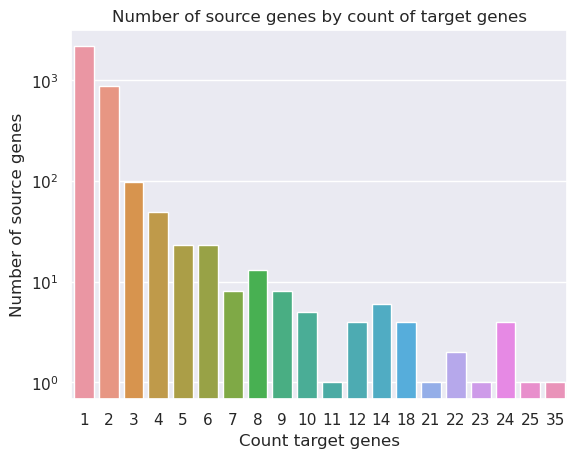

Filtered source DataFrame with target_counts <= 1:


,Marker,Info
0,SLC26A4 ENSG00000091137,Chromaffin cells
1,SLC26A4 ENSG00000091137,Platelets
2,SLC26A4 ENSG00000091137,Intercalated cells
3,SLC26A4 ENSG00000091137,Transient cells
4,AGRP ENSG00000159723,Chromaffin cells
...,...,...
3709,LMNA ENSG00000160789,Embryonic stem cells
3710,TAF8 ENSG00000137413,Embryonic stem cells
3711,HMGA2 ENSG00000149948,Embryonic stem cells
3712,ESRRB ENSG00000119715,Embryonic stem cells


Filtered: 4336 source genes, 53.86%
Create DataFrame containing the transferred genes based on the filter criteria.
Marker transfer rate: 100.00%
Marker transfer rate after filtering: 99.00%
Possible transfer rate of all genes: 35.96%
Proportion of transferred genes in all genes of target organism: 67.35%
Transferred markers:


,Marker,Info
0,CRYL1 ENSDARG00000003675,Proximal tubule cells
1,CLDN17 ENSDARG00000099950,Distal tubule cells
2,CLDN17 ENSDARG00000099950,Loop of Henle cells
3,CBY1 ENSDARG00000077409,Germ cells
4,POU4F1 ENSDARG00000005559,Retinal ganglion cells
...,...,...
3709,RYR2B ENSDARG00000003706,Neurons
3710,RYR2B ENSDARG00000003706,Cardiomyocytes
3711,CSF3R ENSDARG00000045959,Microglia
3712,CSF3R ENSDARG00000045959,Monocytes


Transferring Panglao ubiquitousness index to zebrafish...
Weighted transferred markers:


,Marker,Info,Score
2934,PFN1 ENSDARG00000088091,Osteocytes,0.0
56,RNF152 ENSDARG00000087782,Photoreceptor cells,0.0
2853,FAM167B ENSDARG00000100426,Endothelial cells,0.0
1742,BTK ENSDARG00000004433,Mast cells,0.0
636,LRRK1 ENSDARG00000007398,Fibroblasts,0.0
...,...,...,...
1970,SI:DKEY-30C15.12 ENSDARG00000058546,Mammary epithelial cells,1.0
1972,SI:DKEY-30C15.12 ENSDARG00000058546,Sebocytes,1.0
1971,SI:DKEY-30C15.12 ENSDARG00000058546,Satellite cells,1.0
1961,SI:DKEY-30C15.12 ENSDARG00000058546,Epiblast cells,1.0


Enter file name: 4
Marker list saved: /mnt/workspace/mkessle/projects/annotate_by_marker_and_features/notebooks/transferred_markers/4

Finished!
Do you want to add another marker list? (yes/no): yes
No marker lists found for this organism.
Trying to create marker lists via homology...
Fetching whitelists...
Done!

Loading genes of zebrafish...
Done!

Select lists of source markers.
Available columns for search:
1: List name
2: Marker type
3: Organism name
4: Taxonomy ID
5: Submitter name
6: List type
7: Source
8: tags_transferred
9: Date
10: Email
n: Next page
Enter identifier of column to search in (leave blank to search in all columns): 7
Do you want to see all unique entries in this column? (yes/no) no
Enter search terms (separated by commas, '-' for negative search): bio
Perform an exact search? (yes/no): no
Consider case sensitivity? (yes/no): no
Number of results: 53
Do you want to see the results? (yes/no): no
Do you want to continue searching? (yes/no): no

The following source

,Marker,Info
0,MERTK ENSG00000153208,Macrophage
1,FCGR3A ENSG00000203747,Macrophage
2,MRC1 ENSG00000260314,Macrophage
3,VSIG4 ENSG00000155659,Macrophage
4,CD163 ENSG00000177575,Macrophage
...,...,...
21355,CD3E ENSG00000198851,Conventional CD4 T cell
21356,CD3G ENSG00000160654,Conventional CD4 T cell
21357,CD3D ENSG00000167286,Conventional CD4 T cell
21358,AXL ENSG00000167601,Mesenchymal cell


Filter source DataFrame by the number of target genes per source gene: remove all source genes that lead to more than 1 target genes.
Marker transfer rate: 80.89%
Marker transfer rate after filtering: 57.76%
Possible transfer rate of all genes: 23.07%
Proportion of transferred genes in all genes of target organism: 31.58%

Count of target genes per source gene:


,Source Gene,Count target genes
12026,ZNF729 ENSG00000196350,655
7444,PCDHB3 ENSG00000113205,63
7442,PCDHA8 ENSG00000204962,40
4651,HIST2H2BE,31
7237,OR8G5 ENSG00000255298,25
...,...,...
4293,GPR142 ENSG00000257008,1
4294,GPR143 ENSG00000101850,1
4295,GPR144,1
4296,GPR146 ENSG00000164849,1


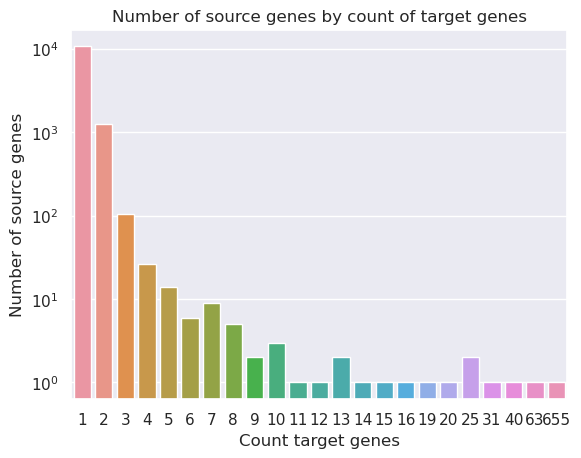

Filtered source DataFrame with target_counts <= 1:


,Marker,Info
0,MERTK ENSG00000153208,Macrophage
1,MERTK ENSG00000153208,M2 macrophage
2,MERTK ENSG00000153208,Microglial cell
3,MERTK ENSG00000153208,Meiotic prophase fetal germ cell
4,MRC1 ENSG00000260314,Macrophage
...,...,...
9786,PLAG1 ENSG00000181690,Granulosa cell
9787,SLC6A8 ENSG00000130821,Granulosa cell
9788,RPP25L ENSG00000164967,Granulosa cell
9789,RPS11 ENSG00000142534,Granulosa cell


Filtered: 9456 source genes, 49.13%
Create DataFrame containing the transferred genes based on the filter criteria.
Marker transfer rate: 99.96%
Marker transfer rate after filtering: 82.78%
Possible transfer rate of all genes: 23.07%
Proportion of transferred genes in all genes of target organism: 31.58%
Transferred markers:


,Marker,Info
0,MERTK,Macrophage
1,MERTK,M2 macrophage
2,MERTK,Microglial cell
3,MERTK,Meiotic prophase fetal germ cell
4,MRC1A ENSDARG00000102100,Macrophage
...,...,...
9786,PLAG1 ENSDARG00000051926,Granulosa cell
9787,SLC6A8 ENSDARG00000043646,Granulosa cell
9788,RPP25L ENSDARG00000070131,Granulosa cell
9789,RPS11 ENSDARG00000053058,Granulosa cell


Transferring Panglao ubiquitousness index to zebrafish...
Selection: drerio

Weighted transferred markers:


,Marker,Info,Score
7345,SLC25A29 ENSDARG00000098849,Ciliated epithelial cell,0.0
8502,ZDHHC13 ENSDARG00000101144,Meiotic prophase fetal germ cell,0.0
8387,JAK2B ENSDARG00000018882,Meiotic prophase fetal germ cell,0.0
8002,ARHGAP15 ENSDARG00000062349,Oogenesis phase fetal germ cell,0.0
8362,AK7B ENSDARG00000017023,Meiotic prophase fetal germ cell,0.0
...,...,...,...
656,CCR7 ENSDARG00000044561,Macrophage,1.0
657,CCR7 ENSDARG00000044561,Progenitor cell,1.0
659,CCR7 ENSDARG00000044561,Effector CD8 T cell,1.0
639,CCR7 ENSDARG00000044561,Central memory T cell,1.0


Enter file name: 5
Marker list saved: /mnt/workspace/mkessle/projects/annotate_by_marker_and_features/notebooks/transferred_markers/5

Starting BioMart approach...

Specify BioMart target organism selection:
Selection: drerio


Specify BioMart source organism selection:
Selection: hsapiens

Loading genes of human...
Done!

Fetch necessary data from BioMart...

DataFrame of the markers of the source organism (human) to be transferred to the target organism (zebrafish):


,Marker,Info
0,MERTK ENSG00000153208,Macrophage
1,FCGR3A ENSG00000203747,Macrophage
2,MRC1 ENSG00000260314,Macrophage
3,VSIG4 ENSG00000155659,Macrophage
4,CD163 ENSG00000177575,Macrophage
...,...,...
21355,CD3E ENSG00000198851,Conventional CD4 T cell
21356,CD3G ENSG00000160654,Conventional CD4 T cell
21357,CD3D ENSG00000167286,Conventional CD4 T cell
21358,AXL ENSG00000167601,Mesenchymal cell


Filter source DataFrame by the number of target genes per source gene: remove all source genes that lead to more than 1 target genes.
Marker transfer rate: 131.41%
Marker transfer rate after filtering: 130.16%
Possible transfer rate of all genes: 35.96%
Proportion of transferred genes in all genes of target organism: 67.35%

Count of target genes per source gene:


,Source Gene,Count target genes
131,CD22 ENSG00000012124,35
1882,HTRA2 ENSG00000115317,25
1613,MS4A6A ENSG00000110077,24
4785,MS4A7 ENSG00000166927,24
3786,MS4A2 ENSG00000149534,24
...,...,...
2495,RNF6 ENSG00000127870,1
2494,TNFRSF19 ENSG00000127863,1
2493,VIL1 ENSG00000127831,1
2492,TUBA4A ENSG00000127824,1


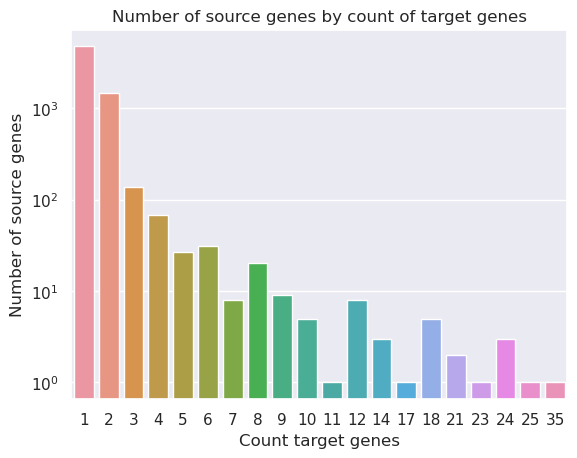

Filtered source DataFrame with target_counts <= 1:


,Marker,Info
0,MERTK ENSG00000153208,Macrophage
1,MERTK ENSG00000153208,M2 macrophage
2,MERTK ENSG00000153208,Microglial cell
3,MERTK ENSG00000153208,Meiotic prophase fetal germ cell
4,UCP1 ENSG00000109424,Brown adipocyte
...,...,...
9308,SNRPC ENSG00000124562,Granulosa cell
9309,SLC6A8 ENSG00000130821,Granulosa cell
9310,HNRNPM ENSG00000099783,Granulosa cell
9311,RPP25L ENSG00000164967,Granulosa cell


Filtered: 9934 source genes, 51.61%
Create DataFrame containing the transferred genes based on the filter criteria.
Marker transfer rate: 100.00%
Marker transfer rate after filtering: 99.36%
Possible transfer rate of all genes: 35.96%
Proportion of transferred genes in all genes of target organism: 67.35%
Transferred markers:


,Marker,Info
0,MT-CO3 ENSDARG00000063912,T cell
1,MT-CO3 ENSDARG00000063912,Monocyte
2,RPS4X ENSDARG00000014690,Leydig cell
3,RPS4X ENSDARG00000014690,B cell
4,CXADR ENSDARG00000043658,Oligodendrocyte
...,...,...
9308,CSF3R ENSDARG00000045959,Lymphoid-primed multipotent progenitor cell(LMPP)
9309,CSF3R ENSDARG00000045959,Common myeloid progenitor cell
9310,CSF3R ENSDARG00000045959,Microglial cell
9311,CSF3R ENSDARG00000045959,Myeloblast


Transferring Panglao ubiquitousness index to zebrafish...
Weighted transferred markers:


,Marker,Info,Score
7026,RSAD2 ENSDARG00000004952,Neutrophil,0.0
8156,ARHGEF1B ENSDARG00000055837,Multilymphoid progenitor cell,0.0
2195,AOC2 ENSDARG00000014646,Prehypertrophic chondrocyte,0.0
5792,RFX2 ENSDARG00000013575,Microglial cell,0.0
805,FOXK1 ENSDARG00000037872,Meiotic prophase fetal germ cell,0.0
...,...,...,...
3012,CR318624.2 ENSDARG00000113438,Naive B cell,1.0
3011,CR318624.2 ENSDARG00000113438,Abnormal plasma cell,1.0
3010,CR318624.2 ENSDARG00000113438,Leukocyte,1.0
3059,CR318624.2 ENSDARG00000113438,Common lymphoid progenitor cell,1.0


Enter file name: 6
Marker list saved: /mnt/workspace/mkessle/projects/annotate_by_marker_and_features/notebooks/transferred_markers/6

Finished!
Do you want to add another marker list? (yes/no): no


In [8]:
marker_lists = wrap.create_marker_lists(organism, repo_path=repo_path, style="score")

## Annotate adata using the created list(s)

Output folder: ./annotation/1/ranked/output/leiden/ 
DB file: /mnt/workspace/mkessle/projects/annotate_by_marker_and_features/notebooks/transferred_markers/1 
Cluster folder: ./annotation/1/ranked/clusters/leiden/ 
Tissue: all
Created folder: ./annotation/1/ranked/clusters/leiden
Created folder: ./annotation/1/ranked/output/leiden
Writing one file per cluster containing gene names and ranked gene scores.
Starting cell type annotation.
./annotation/1 ./annotation/1/ranked/output/leiden leiden
The database contains 1744 different genes.          
The input data contains 17756 different genes.          
The genes of the input data overlap with 1328 genes in total, 76.0 percent.
Adding information to the adata object.
Finished cell type annotation! The results are found in the .obs table cell_types_1.


/home/mkessle/.conda/envs/marker-repo/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/mkessle/.conda/envs/marker-repo/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


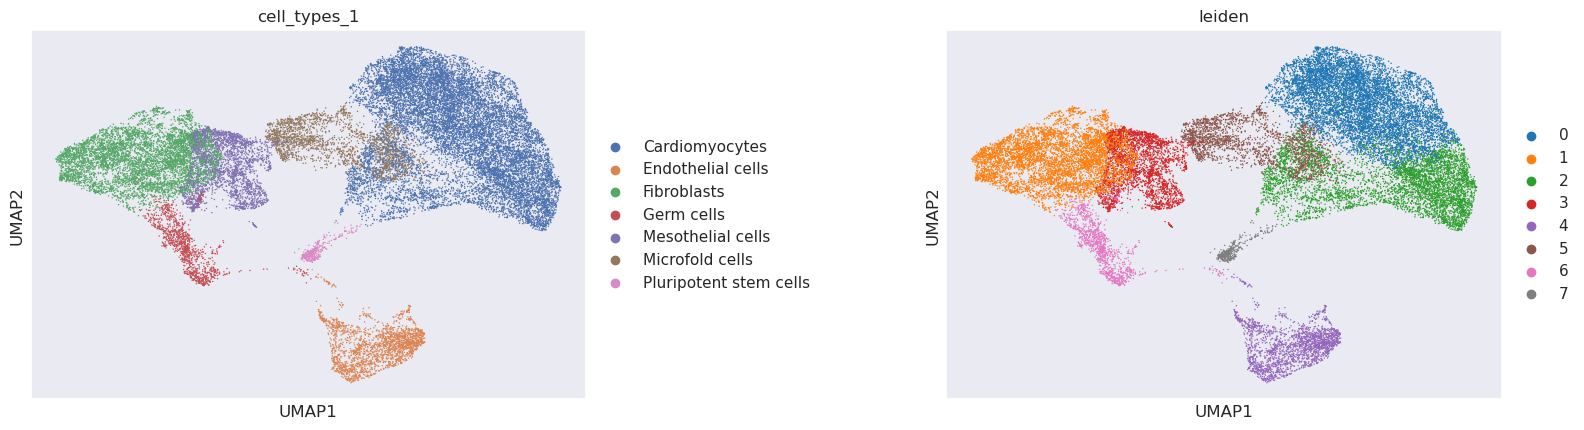

Tables of cell type annotation with clustering leiden


,Cluster 0: Cell type,Score,Hits,Number of marker genes,Mean of UI
0,Cardiomyocytes,865,43,47,14
1,Enterocytes,253,36,65,10
2,Megakaryocytes,101,17,23,4
3,Retinal progenitor cells,78,7,9,2
4,Retinal ganglion cells,59,19,28,27


,Cluster 2: Cell type,Score,Hits,Number of marker genes,Mean of UI
0,Cardiomyocytes,699,43,47,14
1,Enterocytes,449,36,65,10
2,Endothelial cells,293,63,67,15
3,Retinal ganglion cells,165,19,28,27
4,Transient cells,120,10,13,20


,Cluster 5: Cell type,Score,Hits,Number of marker genes,Mean of UI
0,Microfold cells,440,9,13,16
1,B cells,422,21,27,12
2,Transient cells,322,10,13,20
3,T cells,320,18,23,11
4,B cells naive,279,13,15,11


,Cluster 4: Cell type,Score,Hits,Number of marker genes,Mean of UI
0,Endothelial cells,1269,63,67,15
1,Erythroblasts,422,11,14,13
2,Monocytes,411,15,17,14
3,Microfold cells,343,9,13,16
4,Pancreatic progenitor cells,289,7,12,6


...

,Cluster 1: Cell type,Score,Hits,Number of marker genes,Mean of UI
0,Fibroblasts,1341,76,81,8
1,Plasma cells,876,14,18,15
2,Pericytes,790,24,28,7
3,Neuroendocrine cells,774,9,14,22
4,Pancreatic stellate cells,746,14,15,4


,Cluster 6: Cell type,Score,Hits,Number of marker genes,Mean of UI
0,Germ cells,1035,31,43,23
1,Pluripotent stem cells,1013,7,10,24
2,Goblet cells,696,9,12,12
3,Neurons,531,54,87,16
4,Gamma delta T cells,473,11,12,27


,Cluster 7: Cell type,Score,Hits,Number of marker genes,Mean of UI
0,Pluripotent stem cells,759,7,10,24
1,Germ cells,659,31,43,23
2,T cells,336,18,23,11
3,Myoepithelial cells,336,6,7,6
4,B cells,185,21,27,12


Output folder: ./annotation/2/ranked/output/leiden/ 
DB file: /mnt/workspace/mkessle/projects/annotate_by_marker_and_features/notebooks/transferred_markers/2 
Cluster folder: ./annotation/2/ranked/clusters/leiden/ 
Tissue: all
Created folder: ./annotation/2/ranked/clusters/leiden
Created folder: ./annotation/2/ranked/output/leiden
Writing one file per cluster containing gene names and ranked gene scores.
Starting cell type annotation.
./annotation/2 ./annotation/2/ranked/output/leiden leiden
The database contains 1739 different genes.          
The input data contains 17756 different genes.          
The genes of the input data overlap with 1325 genes in total, 76.0 percent.
Adding information to the adata object.
Finished cell type annotation! The results are found in the .obs table cell_types_2.


/home/mkessle/.conda/envs/marker-repo/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/mkessle/.conda/envs/marker-repo/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


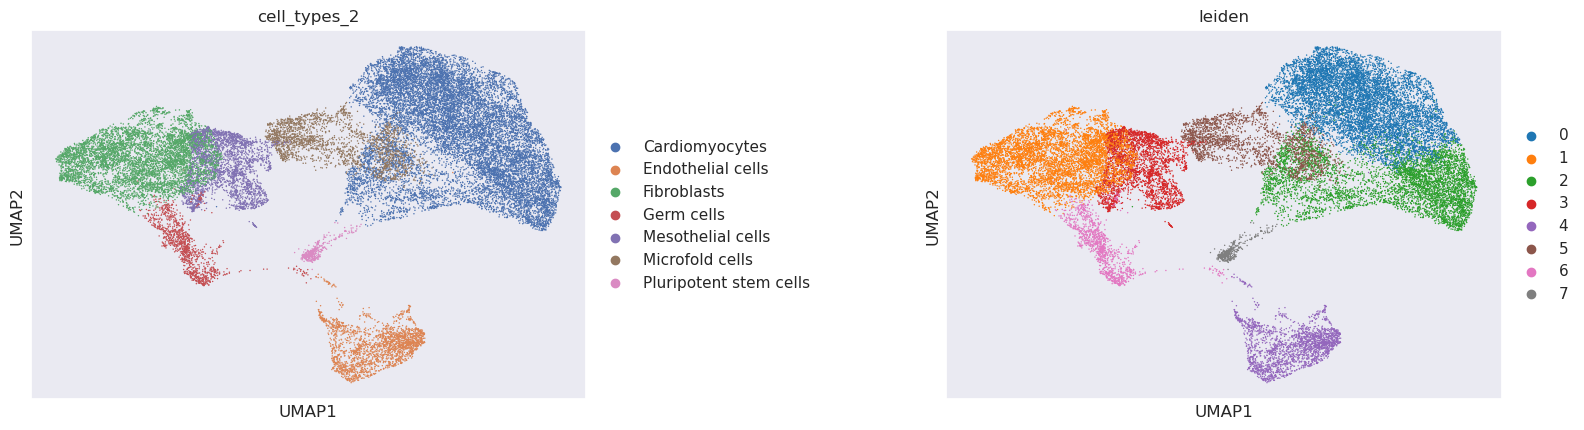

Tables of cell type annotation with clustering leiden


,Cluster 0: Cell type,Score,Hits,Number of marker genes,Mean of UI
0,Cardiomyocytes,828,44,48,15
1,Enterocytes,235,36,68,10
2,Megakaryocytes,101,17,23,4
3,Retinal progenitor cells,78,7,9,2
4,Tuft cells,57,8,16,6


,Cluster 2: Cell type,Score,Hits,Number of marker genes,Mean of UI
0,Cardiomyocytes,732,44,48,15
1,Enterocytes,443,36,68,10
2,Endothelial cells,281,62,67,14
3,B cells,159,17,23,13
4,Transient cells,120,10,13,20


,Cluster 5: Cell type,Score,Hits,Number of marker genes,Mean of UI
0,Microfold cells,440,9,13,16
1,B cells,387,17,23,13
2,Transient cells,322,10,13,20
3,T cells,320,18,23,11
4,Basophils,317,24,28,18


,Cluster 4: Cell type,Score,Hits,Number of marker genes,Mean of UI
0,Endothelial cells,1207,62,67,14
1,Erythroblasts,422,11,14,13
2,Monocytes,399,16,18,13
3,Microfold cells,343,9,13,16
4,Pancreatic progenitor cells,289,7,11,6


...

,Cluster 1: Cell type,Score,Hits,Number of marker genes,Mean of UI
0,Fibroblasts,1348,75,80,8
1,Pericytes,790,24,28,7
2,Neuroendocrine cells,774,9,14,22
3,Plasma cells,756,16,21,17
4,Pancreatic stellate cells,727,15,16,4


,Cluster 6: Cell type,Score,Hits,Number of marker genes,Mean of UI
0,Germ cells,1023,32,43,22
1,Pluripotent stem cells,1013,7,10,24
2,Gamma delta T cells,842,12,13,27
3,Goblet cells,744,8,11,13
4,Neurons,549,53,86,17


,Cluster 7: Cell type,Score,Hits,Number of marker genes,Mean of UI
0,Pluripotent stem cells,759,7,10,24
1,Germ cells,651,32,43,22
2,T cells,336,18,23,11
3,Myoepithelial cells,311,7,8,6
4,B cells,283,17,23,13


Output folder: ./annotation/3/ranked/output/leiden/ 
DB file: /mnt/workspace/mkessle/projects/annotate_by_marker_and_features/notebooks/transferred_markers/3 
Cluster folder: ./annotation/3/ranked/clusters/leiden/ 
Tissue: all
Created folder: ./annotation/3/ranked/clusters/leiden
Created folder: ./annotation/3/ranked/output/leiden
Writing one file per cluster containing gene names and ranked gene scores.
Starting cell type annotation.
./annotation/3 ./annotation/3/ranked/output/leiden leiden
The database contains 2125 different genes.          
The input data contains 17756 different genes.          
The genes of the input data overlap with 1517 genes in total, 71.0 percent.
Adding information to the adata object.
Finished cell type annotation! The results are found in the .obs table cell_types_3.


/home/mkessle/.conda/envs/marker-repo/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/mkessle/.conda/envs/marker-repo/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


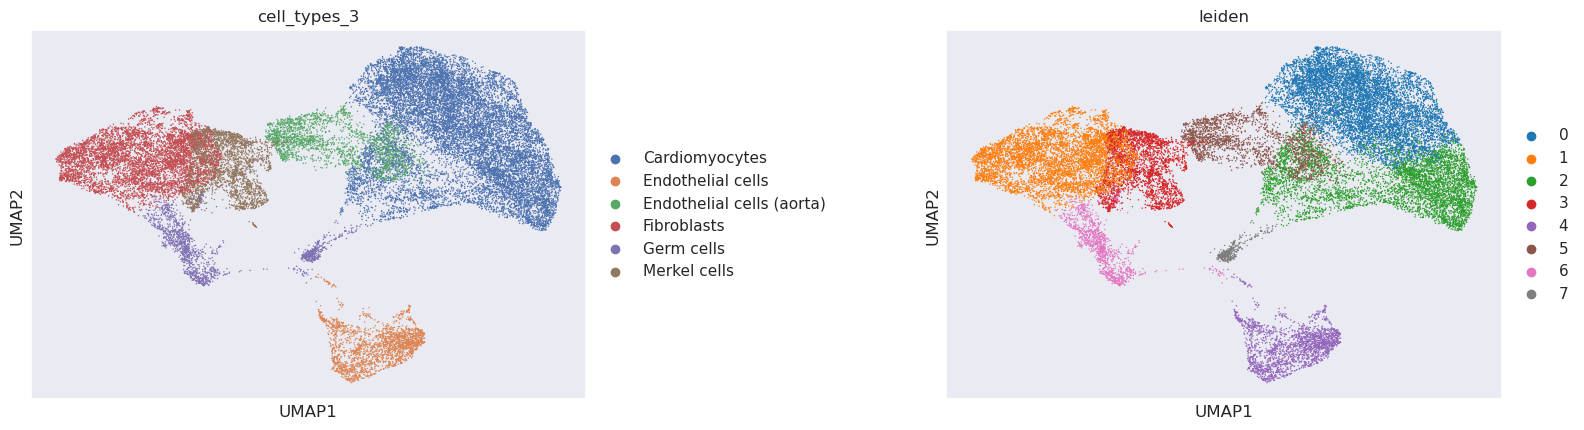

Tables of cell type annotation with clustering leiden


,Cluster 0: Cell type,Score,Hits,Number of marker genes,Mean of UI
0,Cardiomyocytes,602,52,57,14
1,Dopaminergic neurons,268,5,12,14
2,Enterocytes,256,42,80,12
3,T regulatory cells,241,5,8,9
4,Macrophages,103,31,43,12


,Cluster 2: Cell type,Score,Hits,Number of marker genes,Mean of UI
0,Cardiomyocytes,694,52,57,14
1,Enterocytes,501,42,80,12
2,Endothelial cells,349,82,92,15
3,Dopaminergic neurons,265,5,12,14
4,Transient cells,219,9,15,22


,Cluster 5: Cell type,Score,Hits,Number of marker genes,Mean of UI
0,Endothelial cells (aorta),392,46,48,14
1,T cells,391,26,34,11
2,Microfold cells,320,8,16,14
3,Basal cells,306,19,25,17
4,Mesangial cells,297,33,35,15


,Cluster 4: Cell type,Score,Hits,Number of marker genes,Mean of UI
0,Endothelial cells,1749,82,92,15
1,Erythroblasts,391,14,16,11
2,Monocytes,337,21,26,11
3,Tuft cells,317,11,19,11
4,Merkel cells,251,5,10,9


...

,Cluster 1: Cell type,Score,Hits,Number of marker genes,Mean of UI
0,Fibroblasts,1224,73,84,7
1,Müller cells,905,16,23,11
2,Plasma cells,863,18,24,18
3,Melanocytes,746,12,20,15
4,Pancreatic stellate cells,713,13,14,5


,Cluster 6: Cell type,Score,Hits,Number of marker genes,Mean of UI
0,Germ cells,1258,47,64,23
1,Pluripotent stem cells,1033,7,13,24
2,Goblet cells,689,10,15,12
3,B cells,498,26,34,12
4,Gamma delta T cells,489,14,17,26


,Cluster 7: Cell type,Score,Hits,Number of marker genes,Mean of UI
0,Germ cells,843,47,64,23
1,Pluripotent stem cells,756,7,13,24
2,Pyramidal cells,547,8,15,6
3,T cells,327,26,34,11
4,Reticulocytes,251,6,6,12


Output folder: ./annotation/4/ranked/output/leiden/ 
DB file: /mnt/workspace/mkessle/projects/annotate_by_marker_and_features/notebooks/transferred_markers/4 
Cluster folder: ./annotation/4/ranked/clusters/leiden/ 
Tissue: all
Created folder: ./annotation/4/ranked/clusters/leiden
Created folder: ./annotation/4/ranked/output/leiden
Writing one file per cluster containing gene names and ranked gene scores.
Starting cell type annotation.
./annotation/4 ./annotation/4/ranked/output/leiden leiden
The database contains 2120 different genes.          
The input data contains 17756 different genes.          
The genes of the input data overlap with 1513 genes in total, 71.0 percent.
Adding information to the adata object.
Finished cell type annotation! The results are found in the .obs table cell_types_4.


/home/mkessle/.conda/envs/marker-repo/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/mkessle/.conda/envs/marker-repo/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


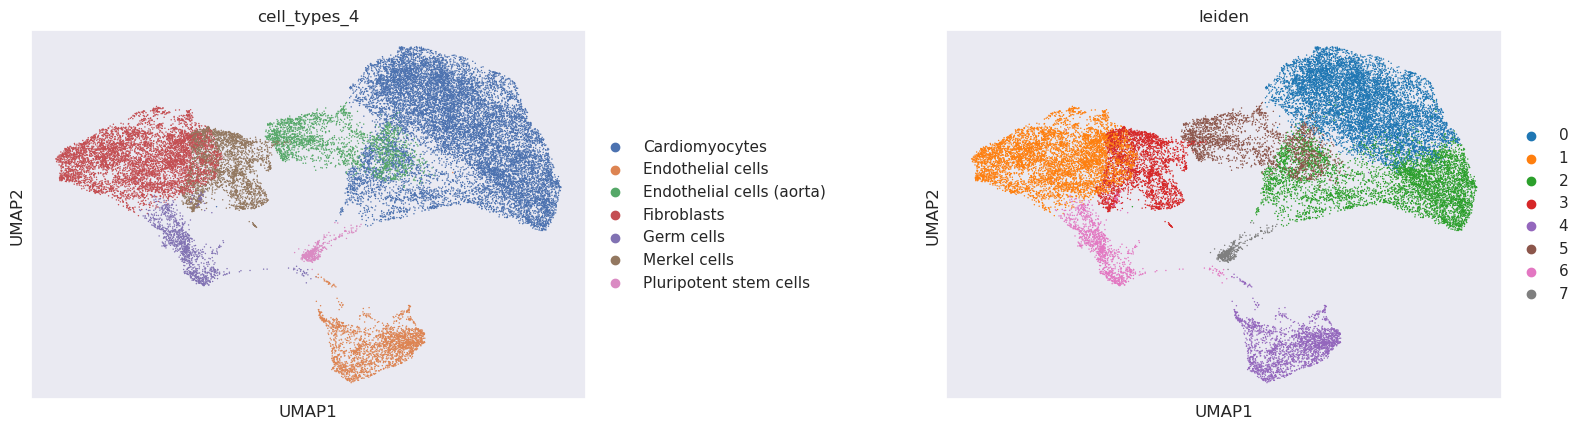

Tables of cell type annotation with clustering leiden


,Cluster 0: Cell type,Score,Hits,Number of marker genes,Mean of UI
0,Cardiomyocytes,781,51,56,13
1,Dopaminergic neurons,268,5,12,14
2,T regulatory cells,241,5,8,9
3,Enterocytes,231,44,83,13
4,Tuft cells,198,9,17,9


,Cluster 2: Cell type,Score,Hits,Number of marker genes,Mean of UI
0,Cardiomyocytes,676,51,56,13
1,Enterocytes,496,44,83,13
2,Endothelial cells,346,82,93,15
3,Dopaminergic neurons,265,5,12,14
4,Transient cells,219,9,14,22


,Cluster 5: Cell type,Score,Hits,Number of marker genes,Mean of UI
0,Endothelial cells (aorta),392,45,47,15
1,T cells,391,26,34,11
2,Purkinje neurons,335,25,33,17
3,Microfold cells,320,8,16,14
4,Mesangial cells,297,33,34,15


,Cluster 4: Cell type,Score,Hits,Number of marker genes,Mean of UI
0,Endothelial cells,1692,82,93,15
1,Tuft cells,473,9,17,9
2,Acinar cells,410,8,12,10
3,Erythroblasts,391,14,16,11
4,Merkel cells,256,6,11,8


...

,Cluster 1: Cell type,Score,Hits,Number of marker genes,Mean of UI
0,Fibroblasts,1322,73,84,8
1,Müller cells,901,16,22,10
2,Plasma cells,762,20,27,19
3,Pancreatic stellate cells,723,12,13,5
4,Melanocytes,707,14,23,15


,Cluster 6: Cell type,Score,Hits,Number of marker genes,Mean of UI
0,Germ cells,1299,47,64,23
1,Pluripotent stem cells,1033,7,14,24
2,Gamma delta T cells,821,15,18,26
3,Goblet cells,689,10,16,12
4,B cells,600,23,31,12


,Cluster 7: Cell type,Score,Hits,Number of marker genes,Mean of UI
0,Pluripotent stem cells,756,7,14,24
1,Germ cells,743,47,64,23
2,Pyramidal cells,547,8,16,6
3,T cells,327,26,34,11
4,Reticulocytes,251,6,6,12


Output folder: ./annotation/5/ranked/output/leiden/ 
DB file: /mnt/workspace/mkessle/projects/annotate_by_marker_and_features/notebooks/transferred_markers/5 
Cluster folder: ./annotation/5/ranked/clusters/leiden/ 
Tissue: all
Created folder: ./annotation/5/ranked/clusters/leiden
Created folder: ./annotation/5/ranked/output/leiden
Writing one file per cluster containing gene names and ranked gene scores.
Starting cell type annotation.
./annotation/5 ./annotation/5/ranked/output/leiden leiden
The database contains 1146 different genes.          
The input data contains 17756 different genes.          
The genes of the input data overlap with 902 genes in total, 79.0 percent.
Adding information to the adata object.
Finished cell type annotation! The results are found in the .obs table cell_types_5.


/home/mkessle/.conda/envs/marker-repo/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/mkessle/.conda/envs/marker-repo/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


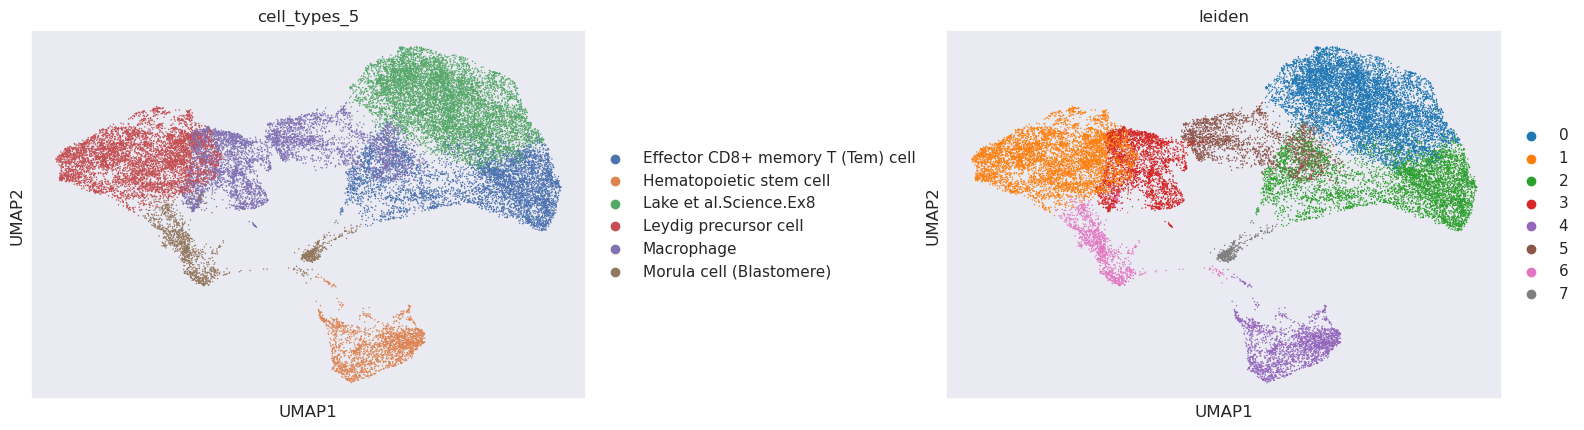

Tables of cell type annotation with clustering leiden


,Cluster 0: Cell type,Score,Hits,Number of marker genes,Mean of UI
0,Lake et al.Science.Ex8,141,9,13,14
1,Epithelial cell,132,16,26,7
2,Neutrophil,78,10,16,6
3,Classical monocyte,69,6,6,2
4,Neural crest cell,65,5,8,3


,Cluster 2: Cell type,Score,Hits,Number of marker genes,Mean of UI
0,Effector CD8+ memory T (Tem) cell,158,14,14,7
1,Lake et al.Science.Ex8,73,9,13,14
2,CD1C+_A dendritic cell,64,6,9,4
3,Neural crest cell,46,5,8,3
4,Classical monocyte,29,6,6,2


,Cluster 5: Cell type,Score,Hits,Number of marker genes,Mean of UI
0,Macrophage,280,29,34,7
1,Proliferative chondrocyte,212,5,5,10
2,Mitotic arrest phase fetal germ cell,192,103,120,9
3,Meiotic prophase fetal germ cell,187,68,83,15
4,Multilymphoid progenitor cell,160,58,68,10


,Cluster 4: Cell type,Score,Hits,Number of marker genes,Mean of UI
0,Hematopoietic stem cell,403,22,27,6
1,CD1C-CD141- dendritic cell,197,36,41,8
2,Epithelial cell,173,16,26,7
3,Endothelial cell,133,67,75,6
4,Trophectoderm cell,73,16,20,9


...

,Cluster 1: Cell type,Score,Hits,Number of marker genes,Mean of UI
0,Leydig precursor cell,1041,51,55,7
1,FGFR1HighNME5- epithelial cell,678,30,33,11
2,Fibroblast,568,21,22,3
3,Astrocyte,529,141,163,9
4,Mesenchymal cell,450,23,23,4


,Cluster 6: Cell type,Score,Hits,Number of marker genes,Mean of UI
0,Morula cell (Blastomere),341,9,9,7
1,CD4+ T cell,324,10,14,6
2,FGFR1HighNME5- epithelial cell,320,30,33,11
3,Plasmacytoid dendritic cell,280,48,55,11
4,Mitotic fetal germ cell,255,65,73,9


,Cluster 7: Cell type,Score,Hits,Number of marker genes,Mean of UI
0,Morula cell (Blastomere),339,9,9,7
1,CD4+ T cell,139,10,14,6
2,CD1C-CD141- dendritic cell,90,36,41,8
3,Proliferative chondrocyte,54,5,5,10
4,Regulatory T (Treg) cell,3,7,7,4


Output folder: ./annotation/6/ranked/output/leiden/ 
DB file: /mnt/workspace/mkessle/projects/annotate_by_marker_and_features/notebooks/transferred_markers/6 
Cluster folder: ./annotation/6/ranked/clusters/leiden/ 
Tissue: all
Created folder: ./annotation/6/ranked/clusters/leiden
Created folder: ./annotation/6/ranked/output/leiden
Writing one file per cluster containing gene names and ranked gene scores.
Starting cell type annotation.
./annotation/6 ./annotation/6/ranked/output/leiden leiden
The database contains 1332 different genes.          
The input data contains 17756 different genes.          
The genes of the input data overlap with 982 genes in total, 74.0 percent.
Adding information to the adata object.
Finished cell type annotation! The results are found in the .obs table cell_types_6.


/home/mkessle/.conda/envs/marker-repo/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/mkessle/.conda/envs/marker-repo/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


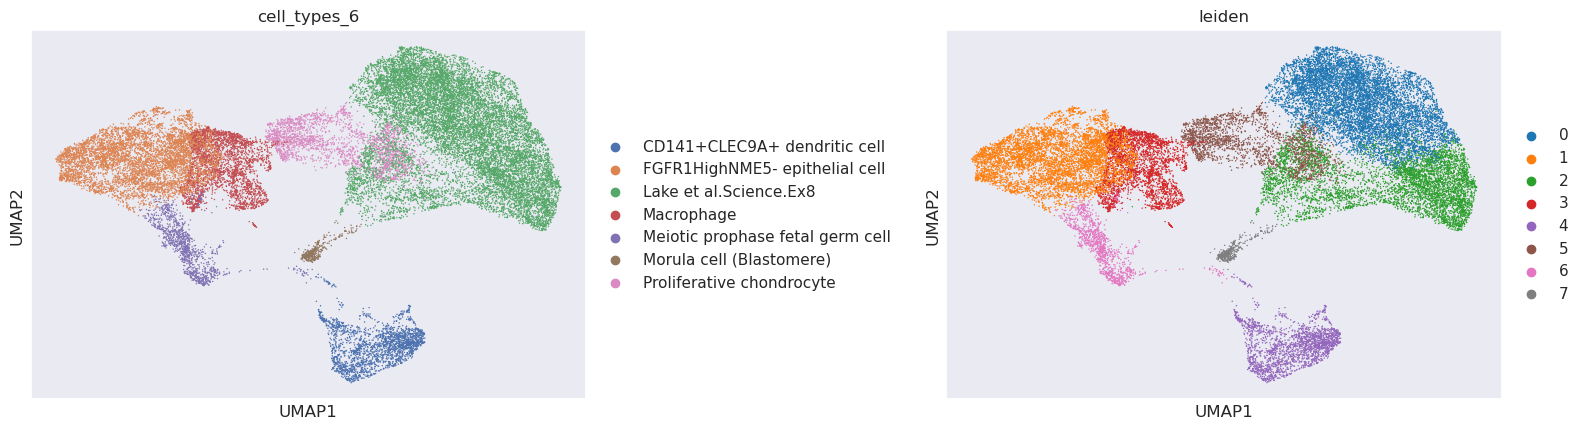

Tables of cell type annotation with clustering leiden


,Cluster 0: Cell type,Score,Hits,Number of marker genes,Mean of UI
0,Lake et al.Science.Ex8,379,5,8,17
1,Proliferative chondrocyte,236,5,5,17
2,Neutrophil,109,9,21,6
3,Classical monocyte,87,6,7,4
4,T cell,65,12,21,4


,Cluster 2: Cell type,Score,Hits,Number of marker genes,Mean of UI
0,Lake et al.Science.Ex8,237,5,8,17
1,Hematopoietic cell,109,8,10,4
2,Effector CD8+ memory T (Tem) cell,108,11,11,7
3,Proliferative chondrocyte,77,5,5,17
4,Classical monocyte,72,6,7,4


,Cluster 5: Cell type,Score,Hits,Number of marker genes,Mean of UI
0,Proliferative chondrocyte,439,5,5,17
1,Basal cell,377,7,10,7
2,Multilymphoid progenitor cell,259,63,81,13
3,Endothelial cell,170,65,75,8
4,Meiotic prophase fetal germ cell,143,80,101,15


,Cluster 4: Cell type,Score,Hits,Number of marker genes,Mean of UI
0,CD141+CLEC9A+ dendritic cell,658,21,23,12
1,Endothelial cell,259,65,75,8
2,Gonadal endothelial cell,174,78,82,10
3,Neural stem cell,167,8,14,4
4,Hematopoietic stem cell,157,24,30,8


,Cluster 3: Cell type,Score,Hits,Number of marker genes,Mean of UI
0,Macrophage,742,34,42,7
1,Migration phase fetal germ cell,336,19,24,8
2,Astrocyte,320,145,178,11
3,Mid radical glial cell,262,5,8,5
4,Epiblast cell,224,11,18,8


,Cluster 1: Cell type,Score,Hits,Number of marker genes,Mean of UI
0,FGFR1HighNME5- epithelial cell,1620,32,36,14
1,Prehypertrophic chondrocyte,1130,13,14,10
2,Leydig precursor cell,1065,44,52,9
3,Astrocyte,906,145,178,11
4,Fibrocartilage chondrocyte,825,33,38,5


,Cluster 6: Cell type,Score,Hits,Number of marker genes,Mean of UI
0,Meiotic prophase fetal germ cell,321,80,101,15
1,Migration phase fetal germ cell,296,19,24,8
2,Mitotic fetal germ cell,285,76,94,10
3,Morula cell (Blastomere),248,9,10,9
4,Myofibroblast,214,6,6,6


,Cluster 7: Cell type,Score,Hits,Number of marker genes,Mean of UI
0,Morula cell (Blastomere),273,9,10,9
1,Basal cell,127,7,10,7
2,CD4+ T cell,92,15,21,8
3,CD1C+_B dendritic cell,48,9,11,6
4,Stem cell,33,18,28,4


In [10]:
for marker_list in marker_lists:
    name = marker_list.split("/")[-1]
    annotation_dir = f"./annotation/{name}"
    
    # Annotate
    annot.annot_ct(adata, output_path=annotation_dir, db_path=marker_list,
                   cluster_column=f"{column}", rank_genes_column=rank_genes_column, 
                   ct_column=f"cell_types_{name}")
    
    # Plot annotation
    sc.pl.umap(adata, color=[f'cell_types_{name}', f'{column}'], wspace=0.5)

    # Show scores and alternate cell types of eacht cluster
    print(f"Tables of cell type annotation with clustering {column}")
    annot.show_tables(annotation_dir=annotation_dir, n=5, clustering_column=column)